In [2]:
import scipy.io as sp
import numpy as np
import matplotlib.pyplot as plt

#funcion para el RMS
def calcular_rms(senal):
    rms = np.sqrt(np.mean(senal**2))
    return rms

# Carga del archivo
datos = sp.loadmat('signals.mat')


Datos cargados correctamente.


In [3]:
print(datos.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


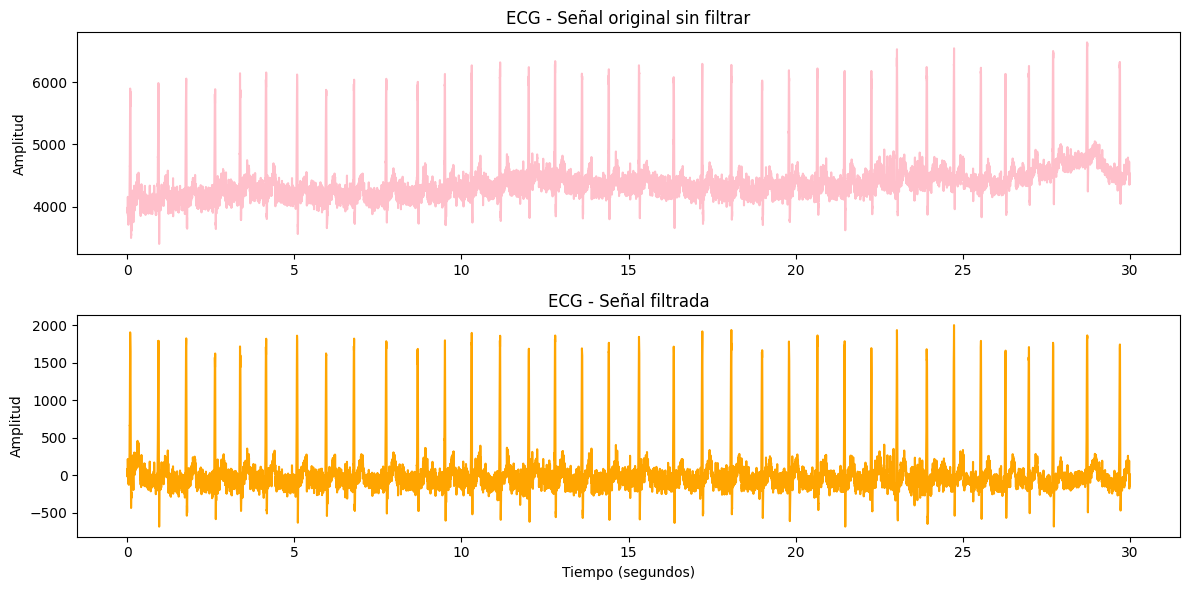

In [3]:
señal_cruda_ecg = datos['ECG_asRecording'].flatten()
señal_filtrada_ecg = datos['ECG_filtered'].flatten()

frecuencia_muestreo = 1024
numero_muestras = len(señal_cruda_ecg)
#vector de tiempo
tiempo = np.arange(numero_muestras) / frecuencia_muestreo

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(tiempo, señal_cruda_ecg, color='pink')
plt.title('ECG - Señal original sin filtrar')
plt.ylabel('Amplitud')

plt.subplot(2, 1, 2)
plt.plot(tiempo, señal_filtrada_ecg, color='orange')
plt.title('ECG - Señal filtrada')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud')
plt.tight_layout()
plt.show()



La señal original (rosada) no es horizontal, se ve como sube y baja lento a lo largo de los 30 segundos, en cambio en la señal filtarda (naranja) esa linea base es mas recta y estable.
Tambien se observa que la señal original oscila como sobre un  nivel DC alto como de 4000 y 6000, en cambio la señal filtarda esta centarda en una amplitud cero y ya no tiene ese offset.
Al observar bien las caracteristicas se ve que la señal original es un poco mas gruesa debido a pequeñas variaciones de alta frecuencia y ya la señal filtarda tiene un trazo mas limpio y deja ver los componentes de la onda cardiaca mas definidps.


Aca se pudo haber utilizado un pasa banda o una combinacion de pasa bajas y pasa altas. en este caso el pasa altas debio haber atenuado las frecuencias cercanas a 0Hz y con eso se elimino ese nivel DC y elimino esa deriva de la linea base que se tenia en la señal sin filtrar que normalmente proviene de ruido de ultra baja frecuencia normalmente < 0.5 Hz que es causada por la respiracion de la persona o el movimiento de los cables.
Y ya la funcion del pasa bajas o un Notch debio ser atenuar las altas frecuencias limpiando como ese grosor de la señal y eliminando interferencias de la red electrica o el ruido muscular que se peude meter en la toma de estas señales.


Frecuencias de interés del ECG
La información diagnóstica útil de un ECG de superficie estándar se ubica en la banda de 0.05 Hz a 100 Hz. Específicamente, la mayor parte de la energía de los complejos QRS se concentra entre los 10 Hz y 25 Hz. El filtro diseñado permitió el paso de esta banda de frecuencias intacta, rechazando los componentes fuera de este rango.


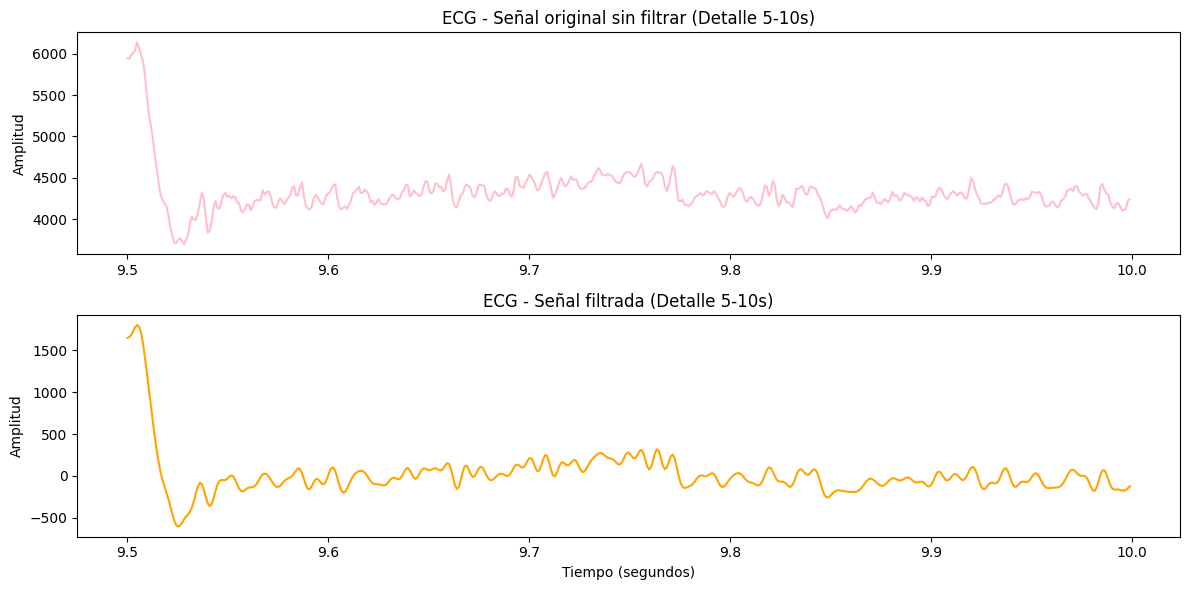

In [9]:
# zoom
iniciozoom = 9.5
finalzoom = 10

muestra_inicio = int(iniciozoom * frecuencia_muestreo)
muestra_final = int(finalzoom * frecuencia_muestreo)

tiempo_zoom = tiempo[muestra_inicio:muestra_final]
señal_crudazoom = señal_cruda_ecg[muestra_inicio:muestra_final]
señal_filtradazoom = señal_filtrada_ecg[muestra_inicio:muestra_final]

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(tiempo_zoom, señal_crudazoom, color='pink')
plt.title(f'ECG - Señal original sin filtrar (Detalle 5-10s)')
plt.ylabel('Amplitud')

plt.subplot(2, 1, 2)
plt.plot(tiempo_zoom, señal_filtradazoom, color='orange')
plt.title(f'ECG - Señal filtrada (Detalle 5-10s)')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud')

plt.tight_layout()
plt.show()

Aca se hizo un zoom para observar mejor como se limpio ese ruido de alta frecuencia que hacia que la señal sin filtrar estuviera como con mas picos y se observa como la señal filtrada es mas estable.

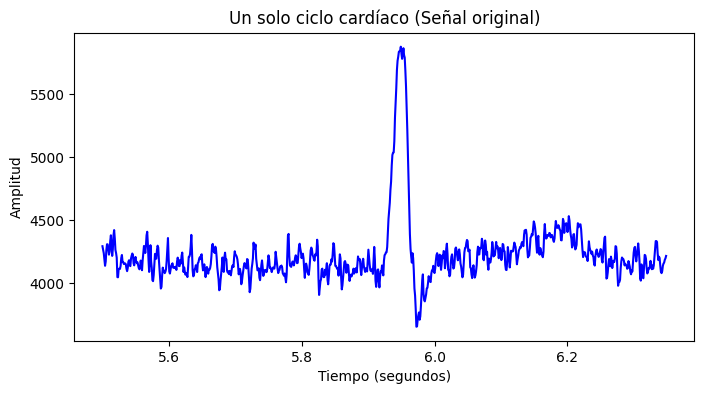

Estadisticas del Ciclo Cardíaco
Promedio: 4226.03
Valor RMS: 4234.57
Varianza: 72263.31
Desviación Estándar: 268.82


In [23]:
inicio_latido = 5.5
fin_latido = 6.35

inicio = int(inicio_latido * frecuencia_muestreo)
fin = int(fin_latido * frecuencia_muestreo)

tiempo_latido = tiempo[inicio:fin]
ciclo_crudo = señal_cruda_ecg[inicio:fin]

plt.figure(figsize=(8, 4))
plt.plot(tiempo_latido, ciclo_crudo, color='blue')
plt.title('Un solo ciclo cardíaco (Señal original)')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud')
plt.show()

promedio = np.mean(ciclo_crudo)
rms = calcular_rms(ciclo_crudo)
varianza = np.var(ciclo_crudo)
desviacion_estandar = np.std(ciclo_crudo)

print("Estadisticas del Ciclo Cardíaco")
print(f"Promedio: {promedio:.2f}")
print(f"Valor RMS: {rms:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación Estándar: {desviacion_estandar:.2f}")

Promedio (4226.03): es la suma de todos los datos dividida por el total de muestras, lo que indica el valor central sobre el que oscila la señal. Este valor tan alto que se obtuvo fue por lo que se habia analizado antes de el offset que traia etsa señal.


Valor RMS (4234.57): Esta medida sirve para ver la magnitud de la energia total que tiene la señal. En este caso el RMS dio casi exactamente lo mismo que el promedio, esto pasa porque ese nivel de fondo de 4000 es tan grande en comparación con el tamaño real del latido que lo que hace es que termina opacando todo.

Desviación Estándar (268.82): Esta nos dice qué tan dispersos o alejados están los datos respecto a ese promedio calculado. Osea muestra qué tanto varía la onda en ese segmento de tiempo. Como la mayor parte del tiempo la señal es solo ruido pequeño, ese valor crece más que todo por el pico grande del QRS, que sube hasta casi 5800 y luego cae de golpe a 3600.

Varianza (72263.31): Esta medida es la desviación estándar elevada al cuadrado, y muestra la variabilidad o fluctuación total de los datos. Esta da un número muy grande que representa toda la energía de los cambios que tiene la señal. Pero como se está evaluando la señal cruda, en ese número tan alto también está metida toda la energía del ruido y la interferencia que aún no se ha limpiado con el filtro.

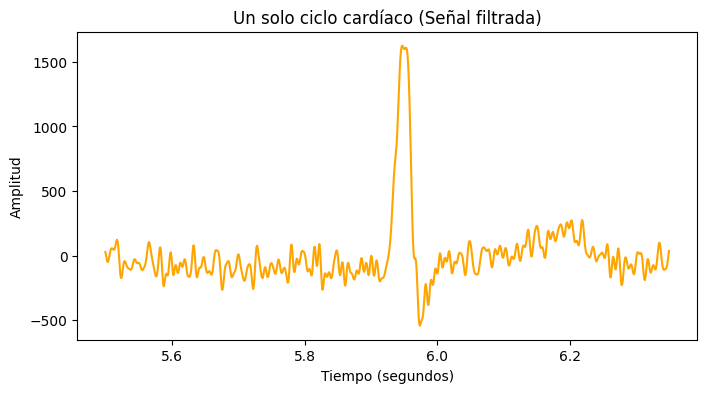

Estadisticas del Ciclo Cardíaco Filtrado
Promedio: -2.58
Valor RMS: 267.03
Varianza: 71297.50
Desviación Estándar: 267.02


In [24]:
ciclo_filtrado = señal_filtrada_ecg[inicio:fin]

plt.figure(figsize=(8, 4))
plt.plot(tiempo_latido, ciclo_filtrado, color='orange')
plt.title('Un solo ciclo cardíaco (Señal filtrada)')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud')
plt.show()

promedio_f = np.mean(ciclo_filtrado)
rms_f = calcular_rms(ciclo_filtrado)
varianza_f = np.var(ciclo_filtrado)
desviacion_estandar_f = np.std(ciclo_filtrado)

print("Estadisticas del Ciclo Cardíaco Filtrado")
print(f"Promedio: {promedio_f:.2f}")
print(f"Valor RMS: {rms_f:.2f}")
print(f"Varianza: {varianza_f:.2f}")
print(f"Desviación Estándar: {desviacion_estandar_f:.2f}")

Promedio: Comparando los dos el de la señal original estaba súper alto (4226.03) y el de la filtrada bajó mucho, a -2.58. Ahí se nota que el filtro sí hizo su trabajo y quitó ese voltaje que traía la señal, dejando la onda centrada alrededor del cero para poder analizarla bien.

Valor RMS: EAca hubo mucho cambio, bajó de 4234.57 a 267.03 y era de esperarse porque como ya se le quitó ese nivel de 4000, ahora el RMS sí está midiendo de verdad la energía del latido. Además se observa ahora el RMS (267.03) quedó casi igual a la desviación estándar (267.02) y eso pasa porque como el promedio ya es prácticamente cero, pues ya no estorba en la fórmula.

Desviación Estándar y Varianza: En estos dos casi no hubo cambio. La desviación pasó de 268.82 a 267.02, bajó solo un poco y la varianza igual (pasó de 72263 a 71297). Esto pasa porque el filtro limpió la basura y el ruido pequeño del fondo pero no dañó la forma del latido ni el pico grande del corazón, entonces el tamaño y la variación de la onda principal siguen siendo prácticamente los mismos.

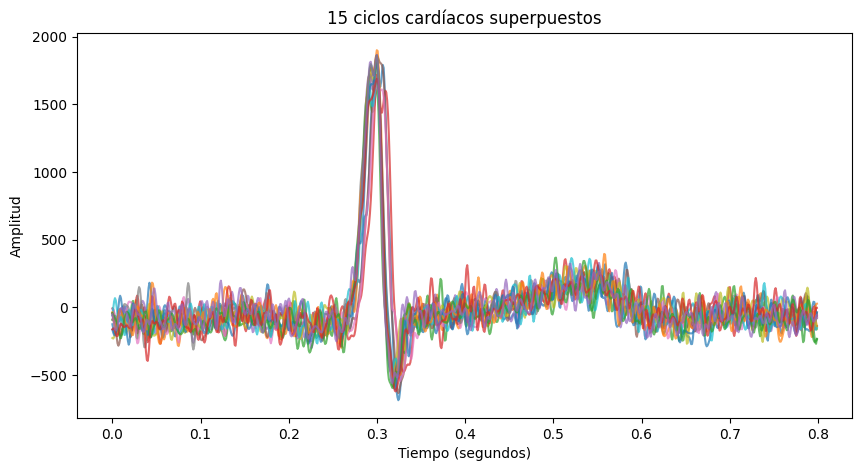

Resultados de los 15 ciclos
Ciclo 1 -> Promedio: 4.89 | Varianza: 88803.92
Ciclo 2 -> Promedio: -5.07 | Varianza: 86646.36
Ciclo 3 -> Promedio: -11.38 | Varianza: 77277.09
Ciclo 4 -> Promedio: 12.50 | Varianza: 78182.99
Ciclo 5 -> Promedio: 8.59 | Varianza: 87554.05
Ciclo 6 -> Promedio: 8.83 | Varianza: 90398.24
Ciclo 7 -> Promedio: 3.64 | Varianza: 74595.23
Ciclo 8 -> Promedio: 13.85 | Varianza: 85690.73
Ciclo 9 -> Promedio: 23.25 | Varianza: 84615.41
Ciclo 10 -> Promedio: 0.64 | Varianza: 77616.30
Ciclo 11 -> Promedio: -2.35 | Varianza: 83352.83
Ciclo 12 -> Promedio: 14.49 | Varianza: 91575.47
Ciclo 13 -> Promedio: -6.21 | Varianza: 92860.44
Ciclo 14 -> Promedio: 10.62 | Varianza: 79937.48
Ciclo 15 -> Promedio: 9.86 | Varianza: 88559.73


In [26]:
from scipy.signal import find_peaks

picos, _ = find_peaks(señal_filtrada_ecg, height=1000, distance=600)

# 15 picos
picos_15 = picos[1:16]

promedios_15 = []
varianzas_15 = []

plt.figure(figsize=(10, 5))

for i, pico in enumerate(picos_15):

    inicio = pico - int(0.3 * frecuencia_muestreo)
    fin = pico + int(0.5 * frecuencia_muestreo)

    ciclo_actual = señal_filtrada_ecg[inicio:fin]

    promedios_15.append(np.mean(ciclo_actual))
    varianzas_15.append(np.var(ciclo_actual))


    tiempo_eje = np.arange(len(ciclo_actual)) / frecuencia_muestreo
    plt.plot(tiempo_eje, ciclo_actual, alpha=0.7)

plt.title('15 ciclos cardíacos superpuestos')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud')
plt.show()

print("Resultados de los 15 ciclos")
for i in range(15):
    print(f"Ciclo {i+1} -> Promedio: {promedios_15[i]:.2f} | Varianza: {varianzas_15[i]:.2f}")

Para obtener los 15 ciclos de forma facil se utilizó una función del código que detecta los picos de la señal. Se definió una altura mínima de 1000 para la búsqueda porque al observar las gráficas que se tenian de la señal filtrada, se ve que el pico principal de cada latido (la onda R) supera fácilmente este valor. Esto ayudo a que se capturara únicamente los latidos reales y no se confundiera con ruido u otras ondas más pequeñas. A partir de esos picos, se recortó una ventana de tiempo y se superpusieron todos para su análisis.


Al observar la gráfica de los 15 ciclos cardíacos superpuestos, aunque todos mantienen la misma morfología básica se ve que ninguno es una copia exacta del otro. Los picos máximos alcanzan diferentes niveles de amplitud, y las pequeñas fluctuaciones antes y después del complejo principal (las ondas P y T) no coinciden bien.

Y eso se afirma mas al mirar los resultados estadísticos calculados para cada ciclo individual. Los valores no se mantienen estables en ningún momento, el promedio varia mucho yendo desde valores negativos como -11.38 (en el ciclo 3) hasta picos positivos de 23.25 (en el ciclo 9). y tambien la varianza presenta saltos constantes moviéndose en un rango que va desde aproximadamente 74595 hasta más de 92860.

¿Se puede considerar que la señal es estacionaria?

Con base en los resultados anteriores, se concluye que la señal no es estacionaria ya que para que una señal se considere estacionaria, sus propiedades estadísticas (como el promedio y la varianza) deben permanecer constantes a lo largo del tiempo. Como en este caso se demostró que tanto la forma gráfica como los valores estadísticos cambian de un latido a otro, se comprueba que la señal del electrocardiograma es de naturaleza estocástica. Estas pequeñas variaciones son completamente normales y reflejan el comportamiento dinámico y continuo del cuerpo humano.